In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
from src.hyperparam_tuning import (
    get_best_tuning_summary,
    get_tuning_results,
    plot_train_validation_gap,
    plot_tuning_results,
    run_hyperparameter_tuning,
)
from sklearn.model_selection import train_test_split
from src.consts import (
    RANDOM_STATE,
    TARGET,
    DATA_PATH,
    TEST_SIZE,
    N_JOBS
)
import pandas as pd

In [3]:
df = pd.read_csv(DATA_PATH)

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

In [6]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((39073, 14), (9769, 14), (39073,), (9769,))

In [7]:
y_train.value_counts(normalize=True)

income
<=50K    0.76073
>50K     0.23927
Name: proportion, dtype: float64

In [8]:
y_test.value_counts(normalize=True)

income
<=50K    0.760672
>50K     0.239328
Name: proportion, dtype: float64

In [9]:
search = run_hyperparameter_tuning(
    X_train=X_train,
    y_train=y_train,
    n_jobs=2,
    verbose=1,
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [10]:
tuning_results = get_tuning_results(search)

tuning_results.head(10)

,rank_test_f1_macro,mean_test_accuracy,std_test_accuracy,mean_test_precision_macro,std_test_precision_macro,mean_test_recall_macro,std_test_recall_macro,mean_test_f1_macro,std_test_f1_macro,mean_test_roc_auc,std_test_roc_auc,mean_train_f1_macro,std_train_f1_macro,mean_fit_time,params
21,1,0.868656,0.005400,0.836718,0.010172,0.783895,0.006570,0.805023,0.007465,0.923843,0.002833,0.810896,0.002971,5.571503,"{'model__learning_rate': 0.08, 'model__max_dep..."
23,2,0.868246,0.005348,0.835265,0.009711,0.784396,0.006747,0.804902,0.007513,0.923471,0.003409,0.810592,0.001782,5.384042,"{'model__learning_rate': 0.08, 'model__max_dep..."
13,3,0.865687,0.004840,0.835291,0.008896,0.775125,0.007554,0.798326,0.007424,0.920285,0.003350,0.801932,0.001947,4.929025,"{'model__learning_rate': 0.05, 'model__max_dep..."
15,4,0.865534,0.004811,0.834864,0.009643,0.775208,0.006271,0.798262,0.006756,0.920080,0.003444,0.802329,0.002171,4.953040,"{'model__learning_rate': 0.05, 'model__max_dep..."
19,5,0.863461,0.004643,0.833115,0.009414,0.770106,0.006436,0.794018,0.006700,0.918204,0.003388,0.797084,0.001857,3.846626,"{'model__learning_rate': 0.08, 'model__max_dep..."
17,6,0.863333,0.004456,0.832701,0.008876,0.770132,0.006067,0.793930,0.006434,0.918226,0.003346,0.796780,0.001803,3.768350,"{'model__learning_rate': 0.08, 'model__max_dep..."
22,7,0.863716,0.004099,0.834565,0.008631,0.769137,0.005255,0.793746,0.005726,0.918833,0.003278,0.797130,0.001931,2.782956,"{'model__learning_rate': 0.08, 'model__max_dep..."
20,8,0.863793,0.004196,0.834999,0.008299,0.768821,0.005701,0.793644,0.006095,0.918823,0.002731,0.797885,0.002462,2.796367,"{'model__learning_rate': 0.08, 'model__max_dep..."
7,9,0.861592,0.004908,0.834727,0.009918,0.761655,0.006821,0.788129,0.007301,0.915469,0.003395,0.790335,0.001551,4.810914,"{'model__learning_rate': 0.03, 'model__max_dep..."
5,10,0.861080,0.004894,0.833859,0.009726,0.760879,0.006630,0.787311,0.007251,0.915599,0.003289,0.790209,0.001667,4.841451,"{'model__learning_rate': 0.03, 'model__max_dep..."


In [ ]:
get_best_tuning_summary(search)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Top 10 tuning configurations by mean_test_f1_macro'}, xlabel='mean_test_f1_macro', ylabel='configuration'>)

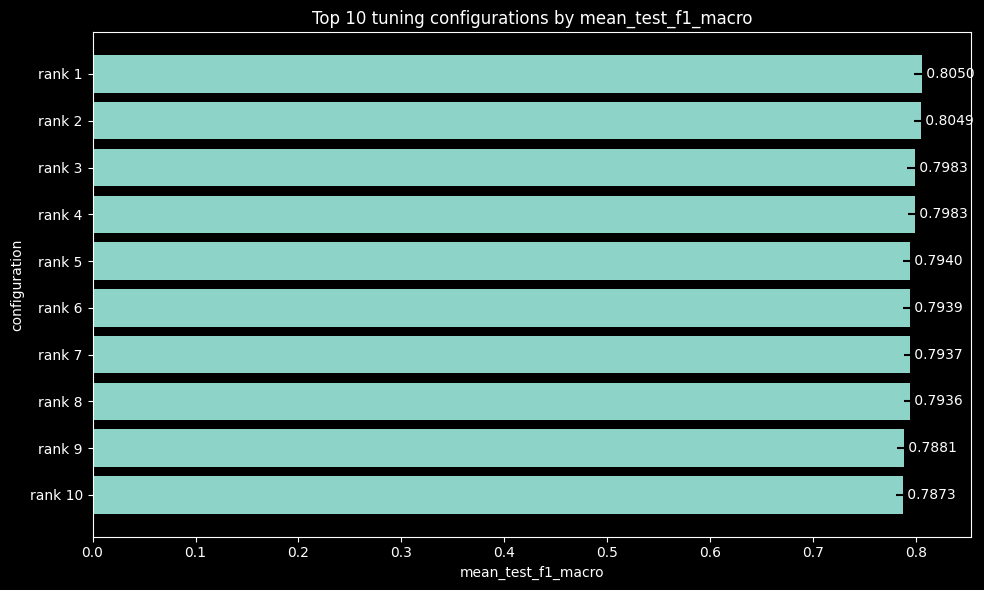

In [12]:
plot_tuning_results(
    tuning_results,
    metric="mean_test_f1_macro",
    top_n=10,
)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Train vs CV f1_macro for top 10 configurations'}, xlabel='configuration rank', ylabel='f1_macro'>)

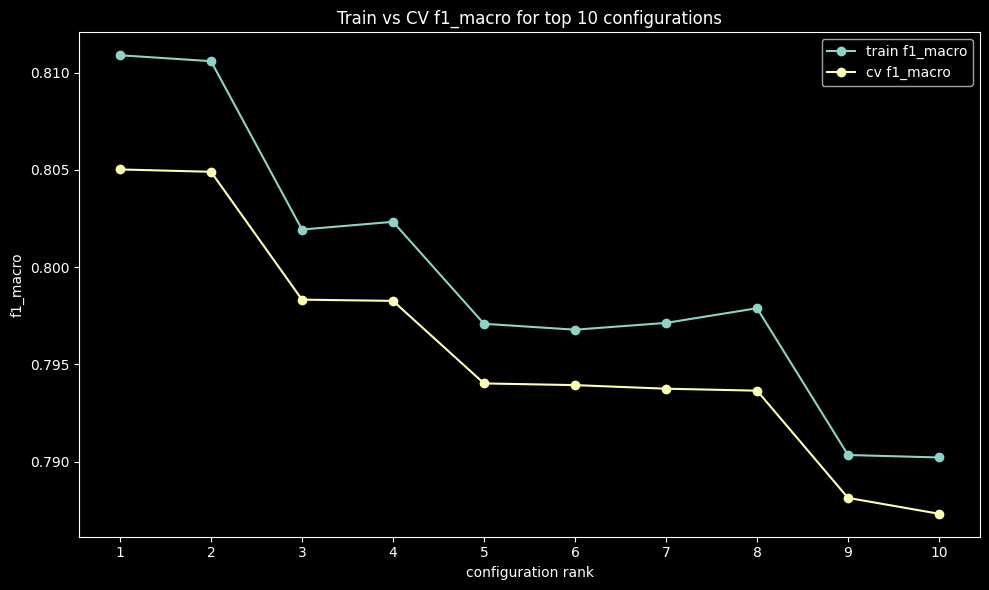

In [13]:
plot_train_validation_gap(
    tuning_results,
    top_n=10,
)